# Scaling Laws en Modelos de Lenguaje

**Duración estimada:** ~2 horas  
**Nivel:** Intermedio–avanzado  
**Complementa:** `../02_modelos_lenguaje/02_modelos_lenguaje.ipynb` y su `.md`

> *"If you want to make a better language model, make it bigger."*  
> — parafraseando Kaplan et al. (2020)

> *"For compute-optimal training, for every doubling of model size the number of training tokens should also be doubled."*  
> — Hoffmann et al. (2022)

---

## ¿Por qué un notebook entero sobre scaling laws?

Porque las **leyes de escala** son el **motor económico y científico** detrás de los LLMs modernos:

- Dado un presupuesto de cómputo `C`, ¿cuánto debería medir mi modelo `N` y cuántos tokens `D` debería ver?
- ¿Cuánto mejorará si duplico mi cluster?
- ¿Cuándo es más útil sobre-entrenar un modelo pequeño que entrenar uno grande?

Las respuestas son cuantitativas, predecibles y **la base** de decisiones de miles de millones de dólares en la industria.

## Agenda

| Bloque | Tema |
|--------|------|
| 1 | Primer sobre leyes de potencia |
| 2 | Las tres leyes de Kaplan-McCandlish (KM, 2020) |
| 3 | Derivación del *compute-optimal frontier* |
| 4 | La ley Chinchilla (Hoffmann et al., 2022) |
| 5 | KM vs Chinchilla — comparación cuantitativa |
| 6 | Verificación empírica a pequeña escala |
| 7 | Post-Chinchilla: over-training e inferencia |
| 8 | Calculadora práctica |
| 9 | Scaling laws más allá del texto |
| 10 | Recursos y ejercicios |

---
## 0. Instalación e imports

In [1]:
!uv pip install numpy scipy matplotlib pandas torch

Using Python 3.11.13 environment at: /home/robert/Documents/Trabajo/Semillero investigación/introduccion_al_nlp/.venv
Audited 5 packages in 11ms


In [2]:
import math
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar, curve_fit

np.random.seed(42)
plt.rcParams['figure.dpi'] = 100
print('Listo.')

Listo.


---
## 1. Primer sobre leyes de potencia

Una **ley de potencia** describe una relación del tipo:

$$y = a \cdot x^{-\alpha}$$

Si graficamos `log(y)` vs `log(x)`, obtenemos una **línea recta** con pendiente `-α`.

Este patrón aparece por doquier en la naturaleza y la ciencia:

| Fenómeno | Ley |
|----------|-----|
| Frecuencia de palabras (Zipf) | `frecuencia ∝ 1/rank` |
| Distribución de riqueza (Pareto) | `P(X > x) ∝ x⁻α` |
| Terremotos (Gutenberg-Richter) | `N ∝ 10⁻ᵇᴹ` |
| **Cross-entropy de un LM vs tamaño** | `L ∝ N⁻ᵅ` |

### 1.1 Demo: generando datos power-law y ajustándolos

Verdadero:  a = 100.00, alpha = 0.400
Ajustado :  a = 104.01, alpha = 0.406


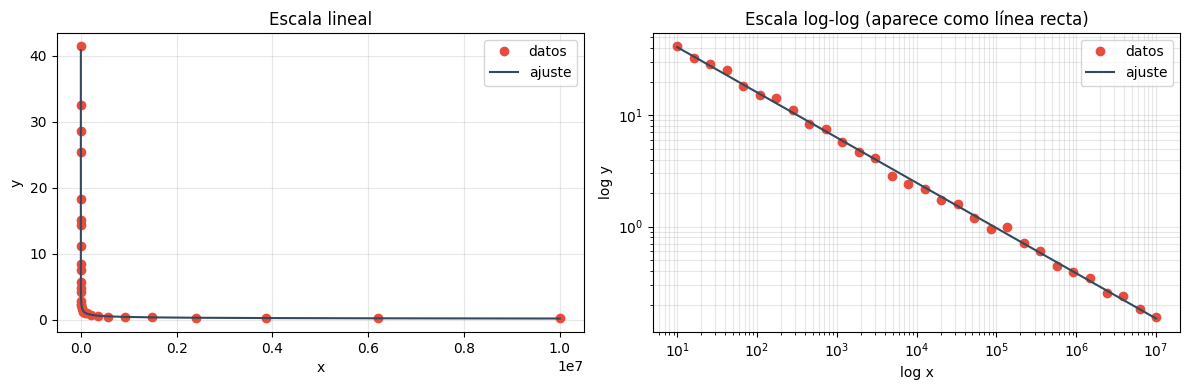

In [3]:
# Generamos datos y(x) = a x^(-alpha) + ruido, y ajustamos la ley
a_true, alpha_true = 100.0, 0.4
xs = np.logspace(1, 7, 30)
y_clean = a_true * xs ** (-alpha_true)
ys = y_clean * np.random.lognormal(mean=0, sigma=0.08, size=len(xs))

# Ajuste en espacio log (regresión lineal sobre log x, log y)
logx, logy = np.log(xs), np.log(ys)
slope, intercept = np.polyfit(logx, logy, 1)
alpha_fit = -slope
a_fit = np.exp(intercept)

print(f'Verdadero:  a = {a_true:.2f}, alpha = {alpha_true:.3f}')
print(f'Ajustado :  a = {a_fit:.2f}, alpha = {alpha_fit:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(xs, ys, 'o', color='#e74c3c', label='datos')
axes[0].plot(xs, a_fit * xs ** (-alpha_fit), '-', color='#34495e', label='ajuste')
axes[0].set_title('Escala lineal')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].loglog(xs, ys, 'o', color='#e74c3c', label='datos')
axes[1].loglog(xs, a_fit * xs ** (-alpha_fit), '-', color='#34495e', label='ajuste')
axes[1].set_title('Escala log-log (aparece como línea recta)')
axes[1].set_xlabel('log x'); axes[1].set_ylabel('log y'); axes[1].legend(); axes[1].grid(alpha=0.3, which='both')
plt.tight_layout(); plt.show()

**Claves de las leyes de potencia**:

- Son **libres de escala**: se comportan igual a cualquier magnitud.
- En log-log son **rectas**. Si en tu dato log-log ves una recta, sospecha una ley de potencia.
- `α` es la única cantidad que importa: controla qué tan rápido decae.

La observación clave de OpenAI en 2020 fue: **la pérdida de un LM decae como ley de potencia** cuando aumentas parámetros, datos o cómputo. Y lo hace con `α` sorprendentemente estable entre escalas.

---
## 2. Las tres leyes de Kaplan-McCandlish (KM, 2020)

En el paper *"Scaling Laws for Neural Language Models"* (arXiv:2001.08361), Kaplan et al. encontraron que la **cross-entropy `L`** de un LM sigue leyes de potencia cuando variamos cualquiera de los tres recursos: parámetros, datos, cómputo.

### 2.1 Ley por parámetros (tamaño del modelo)

$$L(N) = \left(\frac{N_c}{N}\right)^{\alpha_N}, \quad \alpha_N \approx 0.076, \quad N_c \approx 8.8 \times 10^{13}$$

donde `N` es el número de parámetros **no-embedding**.

### 2.2 Ley por datos (tamaño del dataset)

$$L(D) = \left(\frac{D_c}{D}\right)^{\alpha_D}, \quad \alpha_D \approx 0.095, \quad D_c \approx 5.4 \times 10^{13}$$

### 2.3 Ley por cómputo

$$L(C) = \left(\frac{C_c}{C}\right)^{\alpha_C}, \quad \alpha_C \approx 0.050$$

donde `C` está en PF-days (1 PF-day ≈ 8.64 × 10²⁰ FLOPs).

### 2.4 Visualizando las tres leyes KM

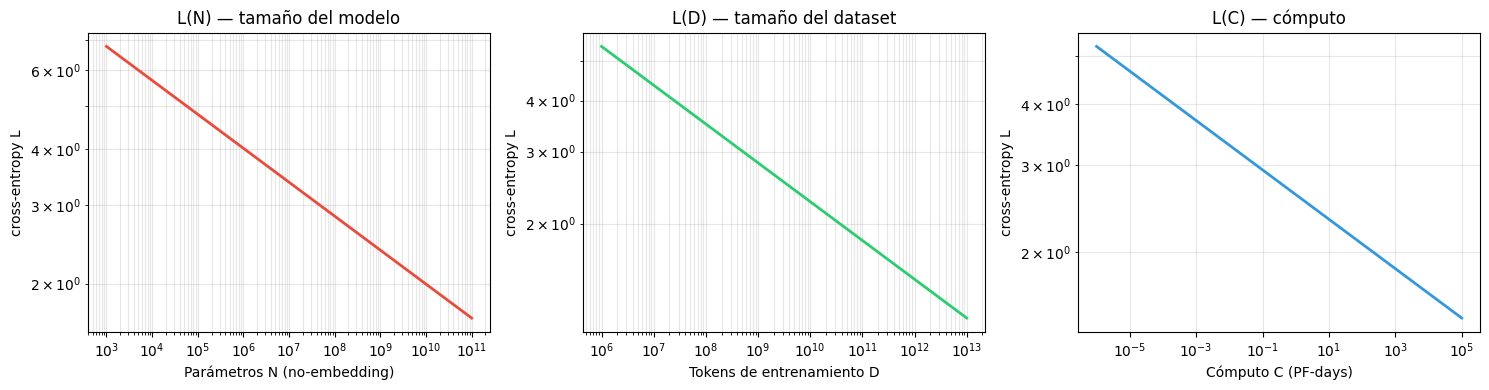

In [4]:
# Constantes aproximadas del paper de Kaplan et al. (2020)
Nc_km = 8.8e13;   alpha_N_km = 0.076
Dc_km = 5.4e13;   alpha_D_km = 0.095
Cc_km = 2.3e8;    alpha_C_km = 0.050  # C en PF-days

def L_de_N(N): return (Nc_km / N) ** alpha_N_km
def L_de_D(D): return (Dc_km / D) ** alpha_D_km
def L_de_C(C): return (Cc_km / C) ** alpha_C_km

Ns = np.logspace(3, 11, 50)   # de 1k a 100B params
Ds = np.logspace(6, 13, 50)   # de 1M a 10T tokens
Cs = np.logspace(-6, 5, 50)   # en PF-days

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (x, y, xlabel, title, color) in zip(axes, [
    (Ns, L_de_N(Ns), 'Parámetros N (no-embedding)', 'L(N) — tamaño del modelo', '#e74c3c'),
    (Ds, L_de_D(Ds), 'Tokens de entrenamiento D', 'L(D) — tamaño del dataset', '#2ecc71'),
    (Cs, L_de_C(Cs), 'Cómputo C (PF-days)',        'L(C) — cómputo',           '#3498db'),
]):
    ax.loglog(x, y, lw=2, color=color)
    ax.set_xlabel(xlabel); ax.set_ylabel('cross-entropy L')
    ax.set_title(title); ax.grid(alpha=0.3, which='both')
plt.tight_layout(); plt.show()

### 2.5 Lectura crítica

Observaciones importantes sobre estas leyes:

1. **Son empíricas**. No hay una teoría completa que las deduzca — son patrones observados.
2. **Los exponentes son pequeños** (~0.05–0.1). Esto significa que **cuesta mucho** bajar la pérdida: para reducirla a la mitad hace falta multiplicar `N` por ~10⁹.
3. **La forma se mantiene a lo largo de muchos órdenes de magnitud**, desde modelos de 1M parámetros hasta 100B+.
4. **Son leyes de *pérdida***, no de capacidades. Una pequeña reducción en `L` puede desbloquear capacidades emergentes cualitativamente nuevas.

---
## 3. Derivación del *compute-optimal frontier*

Ahora la pregunta central: **dado un presupuesto `C`, ¿cómo reparto ese cómputo entre `N` y `D`?**

### 3.1 Restricción de cómputo

Para un transformer, el cómputo de entrenamiento se aproxima como:

$$C \approx 6 \cdot N \cdot D$$

(el factor 6 viene del forward + backward pass; ver apéndice de Kaplan et al.).

### 3.2 El modelo de pérdida conjunta (estilo Chinchilla)

Hoffmann et al. (2022) proponen una forma funcional **paramétrica**:

$$L(N, D) = E + \frac{A}{N^{\alpha}} + \frac{B}{D^{\beta}}$$

Interpretación:

- `E` = pérdida **irreducible** (entropía del lenguaje, cotas de Bayes).
- `A/N^α` = cuánta pérdida se añade por tener un modelo finito.
- `B/D^β` = cuánta pérdida se añade por tener datos finitos.

### 3.3 Optimización con restricción

Queremos minimizar `L(N, D)` sujeto a `C = 6ND` fijo. Usando Lagrangianos:

$$\mathcal{L} = E + \frac{A}{N^{\alpha}} + \frac{B}{D^{\beta}} + \lambda (6ND - C)$$

Derivando e igualando a cero:

$$\frac{\partial \mathcal{L}}{\partial N} = -\alpha A N^{-\alpha - 1} + 6 \lambda D = 0$$
$$\frac{\partial \mathcal{L}}{\partial D} = -\beta B D^{-\beta - 1} + 6 \lambda N = 0$$

Dividiendo una ecuación entre la otra:

$$\frac{\alpha A \cdot N^{-\alpha}}{\beta B \cdot D^{-\beta}} = \frac{D}{N} \cdot \frac{N}{D} \cdot \frac{N}{D} \Rightarrow \alpha A N^{-\alpha} = \beta B D^{-\beta}$$

Es decir: **las contribuciones marginales de `N` y `D` a la pérdida deben estar equilibradas**. De ahí se deriva:

$$N_{\text{opt}}(C) \propto C^{\,a}, \quad D_{\text{opt}}(C) \propto C^{\,b}, \quad a + b = 1$$

Con `α ≈ 0.34` y `β ≈ 0.28` (valores del paper Chinchilla), resulta `a ≈ b ≈ 0.5`: **`N` y `D` deben escalar en proporción a `C^0.5` cada uno**. Es decir, cuando duplicas el cómputo, el modelo crece y los datos crecen **por igual**.

### 3.4 Verificación numérica

In [5]:
# Constantes Chinchilla (paper, Tabla 3, Approach 3)
A_CH, alpha_CH = 406.4, 0.34
B_CH, beta_CH  = 410.7, 0.28
E_CH           = 1.69

def L_chinchilla(N, D):
    return E_CH + A_CH / (N ** alpha_CH) + B_CH / (D ** beta_CH)

def optimo_isocompute(C, n_grid=1000):
    """Dado C = 6 N D, busca el (N*, D*) que minimiza L."""
    Ns = np.logspace(6, 14, n_grid)
    Ds = C / (6 * Ns)
    Ls = L_chinchilla(Ns, Ds)
    i = np.argmin(Ls)
    return Ns[i], Ds[i], Ls[i]

# Barrido de C entre ~1e18 y 1e25 FLOPs
Cs_flops = np.logspace(18, 25, 40)
Nstar = np.zeros_like(Cs_flops)
Dstar = np.zeros_like(Cs_flops)
Lstar = np.zeros_like(Cs_flops)
for i, C in enumerate(Cs_flops):
    Nstar[i], Dstar[i], Lstar[i] = optimo_isocompute(C)

# Ajustar exponentes: N* ∝ C^a y D* ∝ C^b
a_fit, log_kN = np.polyfit(np.log(Cs_flops), np.log(Nstar), 1)
b_fit, log_kD = np.polyfit(np.log(Cs_flops), np.log(Dstar), 1)

print(f'Exponente para N*: a ≈ {a_fit:.3f} (teórico ≈ 0.5)')
print(f'Exponente para D*: b ≈ {b_fit:.3f} (teórico ≈ 0.5)')
print(f'a + b ≈ {a_fit + b_fit:.3f} (debe ser 1)')
print(f'Ratio D*/N* promedio: {(Dstar/Nstar).mean():.1f} tokens por parámetro')

Exponente para N*: a ≈ 0.452 (teórico ≈ 0.5)
Exponente para D*: b ≈ 0.548 (teórico ≈ 0.5)
a + b ≈ 1.000 (debe ser 1)
Ratio D*/N* promedio: 62.1 tokens por parámetro


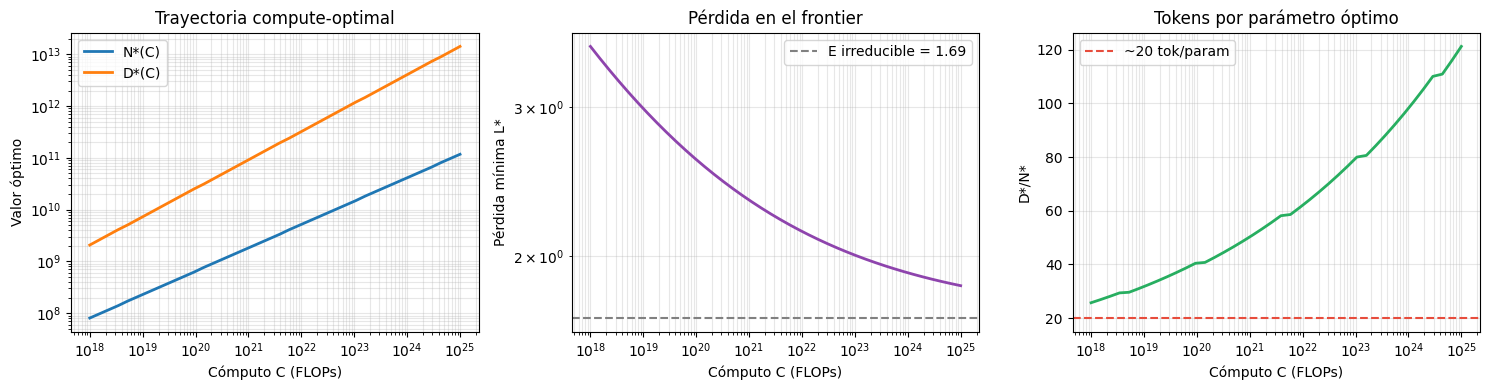

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].loglog(Cs_flops, Nstar, lw=2, label='N*(C)')
axes[0].loglog(Cs_flops, Dstar, lw=2, label='D*(C)')
axes[0].set_xlabel('Cómputo C (FLOPs)')
axes[0].set_ylabel('Valor óptimo')
axes[0].set_title('Trayectoria compute-optimal')
axes[0].grid(alpha=0.3, which='both'); axes[0].legend()

axes[1].loglog(Cs_flops, Lstar, lw=2, color='#8e44ad')
axes[1].axhline(E_CH, ls='--', color='gray', label=f'E irreducible = {E_CH}')
axes[1].set_xlabel('Cómputo C (FLOPs)')
axes[1].set_ylabel('Pérdida mínima L*')
axes[1].set_title('Pérdida en el frontier')
axes[1].grid(alpha=0.3, which='both'); axes[1].legend()

axes[2].semilogx(Cs_flops, Dstar / Nstar, lw=2, color='#27ae60')
axes[2].axhline(20, ls='--', color='#e74c3c', label='~20 tok/param')
axes[2].set_xlabel('Cómputo C (FLOPs)')
axes[2].set_ylabel('D*/N*')
axes[2].set_title('Tokens por parámetro óptimo')
axes[2].grid(alpha=0.3, which='both'); axes[2].legend()

plt.tight_layout(); plt.show()

La trayectoria óptima muestra dos cosas clave:

1. `N` y `D` crecen con **pendientes paralelas** (~0.5) en log-log → se escalan proporcionalmente.
2. El ratio **D/N ≈ 20** para un rango amplio de presupuestos de cómputo → "20 tokens por parámetro" no es casualidad.

---
## 4. La ley Chinchilla (Hoffmann et al., 2022)

El paper de DeepMind *"Training Compute-Optimal Large Language Models"* (arXiv:2203.15556) re-examinó lo de Kaplan con una metodología mejor y llegó a una receta distinta.

### 4.1 Tres enfoques experimentales

Hoffmann et al. usaron **tres métodos independientes** para estimar el trade-off óptimo:

| Approach | Idea | Conclusión |
|----------|------|-----------|
| **1. Fix model, vary data** | Para cada `N`, entrenar con distintas `D` y ver cuál es mejor para un `C` dado | `N ∝ C^0.50`, `D ∝ C^0.50` |
| **2. IsoFLOP curves** | Para cada `C`, variar `N` y encontrar el mínimo | `N ∝ C^0.49`, `D ∝ C^0.51` |
| **3. Fit L(N, D)** | Ajustar la forma paramétrica `L = E + A/N^α + B/D^β` | `N ∝ C^0.46`, `D ∝ C^0.54` |

Los tres coinciden: `N` y `D` deben escalar **casi igual**. El punto clave es que Kaplan había encontrado `a ≈ 0.73`, `b ≈ 0.27`, lo que favorecía modelos gigantescos con pocos datos — resultó ser un artefacto.

### 4.2 Por qué Kaplan se equivocó

La razón principal: **el scheduler de learning rate**. Kaplan usó un cosine schedule cuya duración estaba fijada a un número distinto del número de pasos realmente entrenado, lo que sub-optimizaba los modelos entrenados con muchos datos. Chinchilla corrigió esto.

### 4.3 La validación empírica: Chinchilla 70B vs Gopher 280B

Para probar su receta, DeepMind entrenó dos modelos con **el mismo cómputo**:

| Modelo | Parámetros | Tokens | FLOPs | Ratio D/N | Pérdida val |
|--------|-----------|--------|-------|-----------|-------------|
| **Gopher** | 280B | 300B | ~5.76 × 10²³ | 1.07 | peor |
| **Chinchilla** | 70B | 1.4T | ~5.88 × 10²³ | 20.0 | **mejor** |

Y Chinchilla **superó** a Gopher en casi todos los benchmarks, a pesar de tener **4× menos parámetros**. La receta compute-optimal demostró ser real.

In [7]:
# Comparamos pérdida predicha de Gopher y Chinchilla usando el ajuste del paper
modelos_hist = pd.DataFrame([
    ('GPT-3',      175e9,  300e9,  1.7),
    ('Gopher',     280e9,  300e9,  1.07),
    ('Chinchilla',  70e9, 1400e9, 20.0),
    ('LLaMA 1 65B', 65e9, 1400e9, 21.5),
    ('LLaMA 2 70B', 70e9, 2000e9, 28.6),
    ('LLaMA 3 8B',   8e9, 15000e9, 1875.0),
    ('LLaMA 3 70B', 70e9, 15000e9, 214.3),
], columns=['modelo', 'N', 'D', 'D/N'])

modelos_hist['FLOPs']    = 6 * modelos_hist['N'] * modelos_hist['D']
modelos_hist['L_pred']   = L_chinchilla(modelos_hist['N'].values, modelos_hist['D'].values)
modelos_hist[['modelo', 'N', 'D', 'D/N', 'FLOPs', 'L_pred']]

,modelo,N,D,D/N,FLOPs,L_pred
0,GPT-3,1.750000e+11,3.000000e+11,1.70,3.150000e+23,2.002288
1,Gopher,2.800000e+11,3.000000e+11,1.07,5.040000e+23,1.993258
2,Chinchilla,7.000000e+10,1.400000e+12,20.00,5.880000e+23,1.936645
3,LLaMA 1 65B,6.500000e+10,1.400000e+12,21.50,5.460000e+23,1.938776
4,LLaMA 2 70B,7.000000e+10,2.000000e+12,28.60,8.400000e+23,1.921138
5,LLaMA 3 8B,8.000000e+09,1.500000e+13,1875.00,7.200000e+23,1.948532
6,LLaMA 3 70B,7.000000e+10,1.500000e+13,214.30,6.300000e+24,1.857476


### 4.4 Visualización: ¿dónde se posiciona cada modelo?

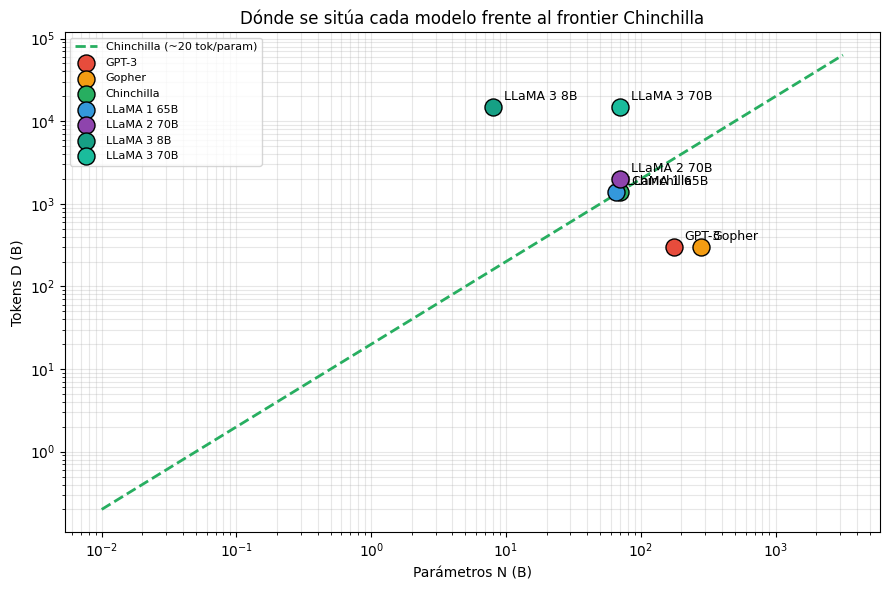

In [8]:
# El frontier compute-optimal en el plano (N, D)
N_grid = np.logspace(7, 12.5, 100)
D_opt_grid = []
for Nc in N_grid:
    # Para cada N, el D* compute-optimal implícito es ~20*N
    D_opt_grid.append(20 * Nc)
D_opt_grid = np.array(D_opt_grid)

plt.figure(figsize=(9, 6))
plt.loglog(N_grid / 1e9, D_opt_grid / 1e9, '--', color='#27ae60', lw=2,
           label='Chinchilla (~20 tok/param)')
# Puntos de referencia
colores = {'GPT-3': '#e74c3c', 'Gopher': '#f39c12', 'Chinchilla': '#27ae60',
           'LLaMA 1 65B': '#3498db', 'LLaMA 2 70B': '#8e44ad', 'LLaMA 3 8B': '#16a085',
           'LLaMA 3 70B': '#1abc9c'}
for _, row in modelos_hist.iterrows():
    plt.scatter(row.N/1e9, row.D/1e9, s=150,
                color=colores.get(row.modelo, 'gray'), edgecolor='black',
                zorder=5, label=row.modelo)
    plt.annotate(row.modelo, (row.N/1e9, row.D/1e9),
                 xytext=(8, 5), textcoords='offset points', fontsize=9)
plt.xlabel('Parámetros N (B)'); plt.ylabel('Tokens D (B)')
plt.title('Dónde se sitúa cada modelo frente al frontier Chinchilla')
plt.grid(alpha=0.3, which='both'); plt.legend(loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()

Observaciones:

- **GPT-3 y Gopher** están muy por **debajo** del frontier → sub-entrenados (demasiados parámetros para tan pocos datos).
- **Chinchilla, LLaMA 1 y LLaMA 2** están cerca del frontier → compute-optimal.
- **LLaMA 3 (especialmente 8B)** está muy por **encima** del frontier → deliberadamente sobre-entrenado (veremos por qué en la sección 7).

---
## 5. KM vs Chinchilla — comparación cuantitativa

¿Cuánto **peor** es la receta KM comparada con Chinchilla a un presupuesto fijo?

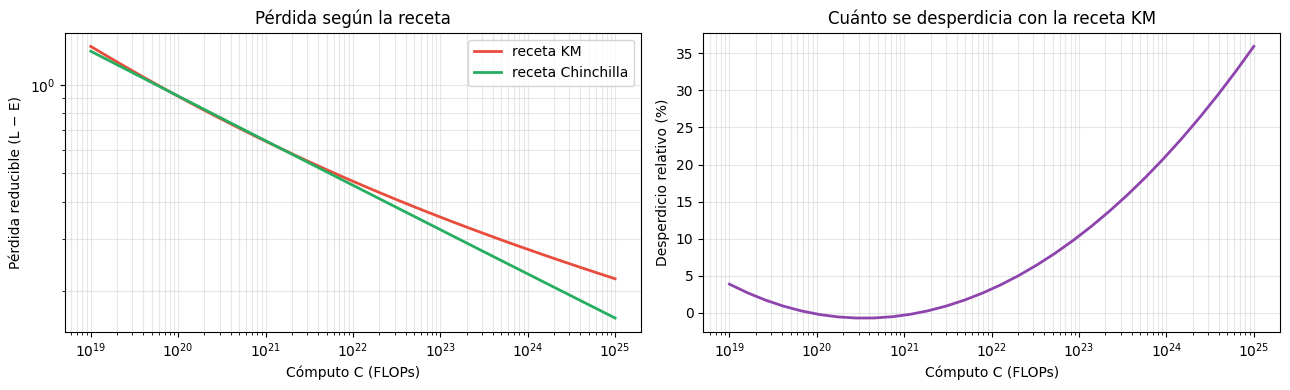

Desperdicio promedio en el rango considerado: 9.1%


In [9]:
# Asumiendo la ley L(N,D) de Chinchilla como verdad de referencia:
# - Receta KM (aprox): N ∝ C^0.73, D ∝ C^0.27
# - Receta Chinchilla: N ∝ C^0.5,  D ∝ C^0.5 (20 tok/param)

def km_NDs(C, a=0.73):
    # Usamos un ratio D/N derivado de GPT-3 (~1.7 tok/param) como ejemplo de la receta KM
    # N ~ (C / (6 * ratio))^0.5 * factor para dar a~0.73 vs b~0.27
    # Simplificación: anclamos al punto de GPT-3
    C_ref = 6 * 175e9 * 300e9
    N_ref, D_ref = 175e9, 300e9
    N = N_ref * (C / C_ref) ** a
    D = D_ref * (C / C_ref) ** (1 - a)
    return N, D

def chinchilla_NDs(C):
    # D = 20 N; C = 6 N (20 N) = 120 N^2  ⇒  N = sqrt(C/120)
    N = np.sqrt(C / 120)
    D = 20 * N
    return N, D

Cs_flops = np.logspace(19, 25, 30)

L_km, L_ch = [], []
for C in Cs_flops:
    N_k, D_k = km_NDs(C)
    N_c, D_c = chinchilla_NDs(C)
    L_km.append(L_chinchilla(N_k, D_k))
    L_ch.append(L_chinchilla(N_c, D_c))

L_km = np.array(L_km); L_ch = np.array(L_ch)
gap = (L_km - L_ch) / (L_ch - E_CH)  # gap relativo sobre la parte reducible

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].loglog(Cs_flops, L_km - E_CH, lw=2, color='#e74c3c', label='receta KM')
axes[0].loglog(Cs_flops, L_ch - E_CH, lw=2, color='#27ae60', label='receta Chinchilla')
axes[0].set_xlabel('Cómputo C (FLOPs)')
axes[0].set_ylabel('Pérdida reducible (L − E)')
axes[0].set_title('Pérdida según la receta')
axes[0].grid(alpha=0.3, which='both'); axes[0].legend()

axes[1].semilogx(Cs_flops, 100 * gap, lw=2, color='#8e44ad')
axes[1].set_xlabel('Cómputo C (FLOPs)')
axes[1].set_ylabel('Desperdicio relativo (%)')
axes[1].set_title('Cuánto se desperdicia con la receta KM')
axes[1].grid(alpha=0.3, which='both')
plt.tight_layout(); plt.show()

print('Desperdicio promedio en el rango considerado:', f'{100*gap.mean():.1f}%')

A cómputos grandes, la receta KM desperdicia un porcentaje **no trivial** de la pérdida reducible. Esto en decisiones de entrenamiento de LLM se traduce en millones de dólares.

---
## 6. Verificación empírica a pequeña escala

Vamos a **entrenar de verdad** varios mini-modelos de distinto tamaño sobre un texto sintético y observar cómo la pérdida final sigue una ley de potencia.

> Esto es una versión en miniatura del experimento de Kaplan: el objetivo no es competir con GPT-3 sino ver la forma de la ley emerger con datos reales.

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Dispositivo:', device)

# Corpus sintético: un lenguaje artificial con estructura
def generar_corpus(n_chars=200_000):
    vocab = list('abcdefghijklmnopqrstuvwxyz ')
    # Mezclamos patrones: ciertas letras siguen otras con mayor probabilidad
    transiciones = np.random.dirichlet(np.ones(len(vocab)) * 0.3, size=len(vocab))
    # Muchos ciclos repetitivos para que el modelo pueda aprender algo
    out = [np.random.randint(len(vocab))]
    for _ in range(n_chars - 1):
        out.append(np.random.choice(len(vocab), p=transiciones[out[-1]]))
    return vocab, np.array(out, dtype=np.int64)

vocab, corpus = generar_corpus(200_000)
V = len(vocab)
data = torch.tensor(corpus, dtype=torch.long)
print(f'Corpus: {len(data):,} caracteres, vocabulario {V}')

Dispositivo: cuda
Corpus: 200,000 caracteres, vocabulario 27


In [11]:
SEQ = 32
BATCH = 128
SPLIT = int(0.9 * len(data))
train_data, val_data = data[:SPLIT], data[SPLIT:]

def get_batch(src):
    ix = torch.randint(len(src) - SEQ - 1, (BATCH,))
    x = torch.stack([src[i:i+SEQ]     for i in ix]).to(device)
    y = torch.stack([src[i+1:i+SEQ+1] for i in ix]).to(device)
    return x, y

class TinyLM(nn.Module):
    """LM char-level muy pequeño para barrido de tamaños."""
    def __init__(self, vocab_size, hidden=32, layers=1):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, hidden)
        self.rnn = nn.GRU(hidden, hidden, num_layers=layers, batch_first=True)
        self.head = nn.Linear(hidden, vocab_size)
    def forward(self, x):
        e = self.emb(x)
        o, _ = self.rnn(e)
        return self.head(o)

def params_count(m):
    return sum(p.numel() for p in m.parameters())

def entrenar(hidden, layers=1, pasos=400, lr=5e-3):
    torch.manual_seed(0)
    m = TinyLM(V, hidden=hidden, layers=layers).to(device)
    opt = torch.optim.AdamW(m.parameters(), lr=lr)
    N = params_count(m)
    for it in range(pasos):
        m.train()
        xb, yb = get_batch(train_data)
        logits = m(xb)
        loss = F.cross_entropy(logits.reshape(-1, V), yb.reshape(-1))
        opt.zero_grad(); loss.backward(); opt.step()
    # Evaluar
    m.eval()
    with torch.no_grad():
        xb, yb = get_batch(val_data)
        vloss = F.cross_entropy(m(xb).reshape(-1, V), yb.reshape(-1)).item()
    return N, vloss

In [12]:
# Barrido de tamaños — esto puede tardar ~1-3 min
hiddens = [8, 12, 16, 24, 32, 48, 64, 96, 128, 192]
resultados = []
t0 = time.time()
for h in hiddens:
    N, L = entrenar(hidden=h, pasos=400)
    resultados.append((h, N, L))
    print(f'hidden={h:3d}  N={N:>8,}  val_loss={L:.4f}  elapsed={time.time()-t0:.1f}s')

df_scaling = pd.DataFrame(resultados, columns=['hidden', 'N', 'L'])
df_scaling

hidden=  8  N=     891  val_loss=2.4572  elapsed=1.9s
hidden= 12  N=   1,611  val_loss=2.3597  elapsed=3.2s
hidden= 16  N=   2,523  val_loss=2.3020  elapsed=4.5s
hidden= 24  N=   4,923  val_loss=2.2679  elapsed=5.8s
hidden= 32  N=   8,091  val_loss=2.2464  elapsed=7.1s
hidden= 48  N=  16,731  val_loss=2.2504  elapsed=8.4s
hidden= 64  N=  28,443  val_loss=2.2469  elapsed=9.7s
hidden= 96  N=  61,083  val_loss=2.2896  elapsed=11.0s
hidden=128  N= 106,011  val_loss=2.3053  elapsed=12.3s
hidden=192  N= 232,731  val_loss=2.2722  elapsed=15.7s


,hidden,N,L
0,8,891,2.457209
1,12,1611,2.359749
2,16,2523,2.301974
3,24,4923,2.267893
4,32,8091,2.246428
5,48,16731,2.250364
6,64,28443,2.246940
7,96,61083,2.289593
8,128,106011,2.305321
9,192,232731,2.272219


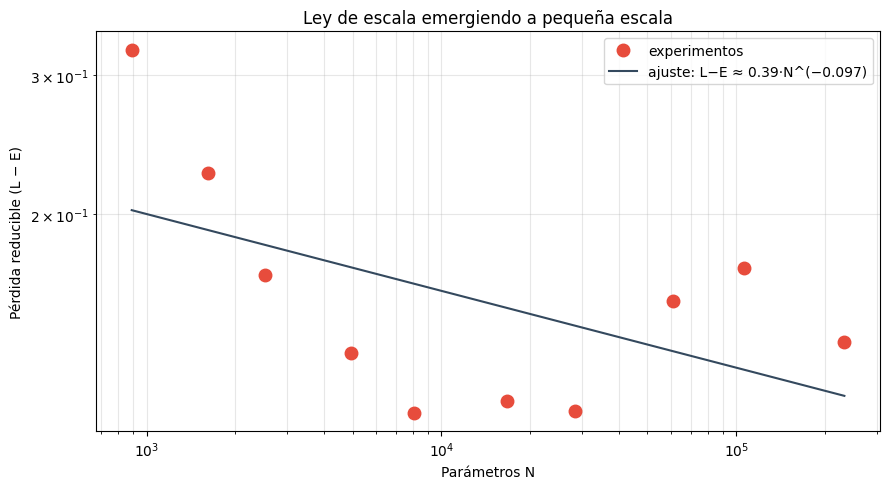

Exponente empírico α ≈ 0.097
(Kaplan reportó α_N ≈ 0.076 para transformers sobre texto natural)


In [13]:
# Ajuste de ley de potencia L - E = A / N^alpha
# Estimamos E como el mínimo - pequeña holgura
E_emp = df_scaling['L'].min() * 0.95
reducible = df_scaling['L'].values - E_emp
logN = np.log(df_scaling['N'].values)
logL = np.log(reducible)

slope, intercept = np.polyfit(logN, logL, 1)
alpha_emp = -slope
A_emp = np.exp(intercept)

Nsmooth = np.logspace(np.log10(df_scaling['N'].min()),
                      np.log10(df_scaling['N'].max()), 100)

plt.figure(figsize=(9, 5))
plt.loglog(df_scaling['N'], reducible, 'o', ms=9, color='#e74c3c', label='experimentos')
plt.loglog(Nsmooth, A_emp * Nsmooth**(-alpha_emp), '-', color='#34495e',
           label=f'ajuste: L−E ≈ {A_emp:.2g}·N^(−{alpha_emp:.3f})')
plt.xlabel('Parámetros N')
plt.ylabel('Pérdida reducible (L − E)')
plt.title('Ley de escala emergiendo a pequeña escala')
plt.grid(alpha=0.3, which='both'); plt.legend()
plt.tight_layout(); plt.show()

print(f'Exponente empírico α ≈ {alpha_emp:.3f}')
print(f'(Kaplan reportó α_N ≈ 0.076 para transformers sobre texto natural)')

Observaciones:

- Con modelos diminutos y un corpus sintético ya se aprecia **una línea recta en log-log** → confirma la forma de la ley.
- El exponente que obtenemos **no coincide numéricamente** con el de Kaplan — depende del problema, arquitectura, regularización, etc. Pero la **forma funcional** es estable.
- El paper original usa ~10² modelos sobre decenas de órdenes de magnitud — aquí hacemos 10 modelos sobre ~2 órdenes.

---
## 7. Post-Chinchilla: over-training e inferencia

Después de Chinchilla, apareció una ola de modelos **deliberadamente sobre-entrenados** (over-trained) respecto a la receta compute-optimal:

| Modelo | N | D | D/N | ¿Compute-optimal? |
|--------|---|---|-----|---|
| Chinchilla | 70B | 1.4T | 20 | ✅ |
| LLaMA 2 7B | 7B | 2T | 286 | 14× overtrained |
| LLaMA 3 8B | 8B | 15T | 1875 | ~94× overtrained |
| Mistral 7B | 7B | ~8T | ~1143 | ~57× overtrained |

### 7.1 ¿Por qué sobre-entrenar si es "sub-óptimo"?

Porque **el cómputo no termina en el entrenamiento**. Cuando sirves un modelo a millones de usuarios, el cómputo de **inferencia** supera por mucho al de entrenamiento. Y ahí, modelos más pequeños son mucho más baratos.

**Coste total ≈ Coste_entrenamiento + Coste_inferencia_acumulado**

Si sabes que vas a servir el modelo a escala masiva, compensa entrenar un modelo **más pequeño** por **más tiempo** — aunque eso signifique "desperdiciar" cómputo en entrenamiento según la métrica de Chinchilla.

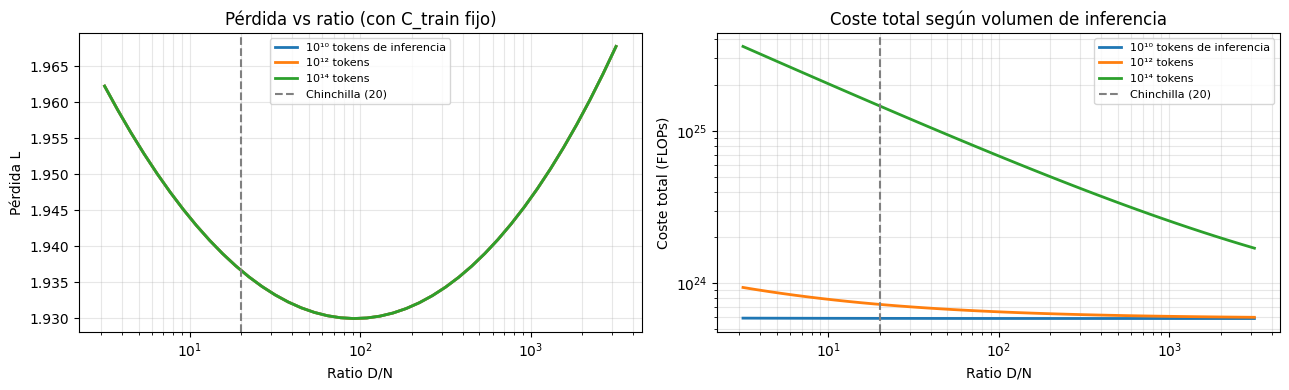

In [14]:
# Coste total = entrenamiento (una sola vez) + inferencia × peticiones
# FLOPs_inferencia ≈ 2 * N por token generado

def coste_total(N, D, peticiones=1e12):
    flops_train = 6 * N * D
    flops_infer = 2 * N * peticiones
    return flops_train, flops_infer, flops_train + flops_infer

# Isocómputo de entrenamiento: C_train fijo, variamos (N, D) sobre el frontier y más allá
C_train_fijo = 6 * 70e9 * 1.4e12  # cómputo de Chinchilla
ratios = np.logspace(0.5, 3.5, 40)  # D/N de ~3 a ~3000

records = []
for r in ratios:
    # D = r * N; C_train = 6 N * r N = 6 r N^2  ⇒  N = sqrt(C/(6 r))
    N = np.sqrt(C_train_fijo / (6 * r))
    D = r * N
    L = L_chinchilla(N, D)
    for peticiones in [1e10, 1e12, 1e14]:
        ft, fi, tot = coste_total(N, D, peticiones)
        records.append({'ratio': r, 'N': N, 'D': D, 'L': L,
                        'peticiones': peticiones, 'C_total': tot,
                        'C_inf': fi, 'C_train': ft})
df_post = pd.DataFrame(records)

# Para cada nivel de peticiones, cuál es el mejor L viable con el menor coste total
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for pet, label in [(1e10, '10¹⁰ tokens de inferencia'),
                    (1e12, '10¹² tokens'),
                    (1e14, '10¹⁴ tokens')]:
    sub = df_post[df_post['peticiones'] == pet]
    axes[0].semilogx(sub['ratio'], sub['L'], lw=2, label=label)
    axes[1].loglog(sub['ratio'], sub['C_total'], lw=2, label=label)

axes[0].axvline(20, ls='--', color='gray', label='Chinchilla (20)')
axes[0].set_xlabel('Ratio D/N'); axes[0].set_ylabel('Pérdida L')
axes[0].set_title('Pérdida vs ratio (con C_train fijo)')
axes[0].grid(alpha=0.3, which='both'); axes[0].legend(fontsize=8)

axes[1].axvline(20, ls='--', color='gray', label='Chinchilla (20)')
axes[1].set_xlabel('Ratio D/N'); axes[1].set_ylabel('Coste total (FLOPs)')
axes[1].set_title('Coste total según volumen de inferencia')
axes[1].grid(alpha=0.3, which='both'); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

Observa cómo la estrategia óptima cambia con el volumen de inferencia esperado:

- **Poca inferencia** → receta Chinchilla (ratio ~20).
- **Mucha inferencia** → conviene sobre-entrenar (ratio mayor) para obtener un modelo más pequeño que sea más barato de servir.

Este es exactamente el razonamiento detrás de LLaMA 3 8B entrenado sobre 15T tokens.

### 7.2 Sardanashvily et al. y Sardanashvili overtraining laws

Trabajos recientes (Sardinha et al. 2024, Gadre et al. 2024 "Language models scale reliably with over-training") muestran que **la forma funcional `L(N, D)` sigue siendo válida** mucho más allá de la zona Chinchilla — la overtraining no "rompe" las scaling laws, solo cambia el punto de operación.

---
## 8. Calculadora práctica

Traduzcamos todo esto en herramientas que puedas usar tú misma/o.

In [15]:
def recomendar_compute_optimal(presupuesto_flops):
    """Dado un presupuesto en FLOPs, devuelve la receta Chinchilla (N*, D*, L*)."""
    N = np.sqrt(presupuesto_flops / 120)   # de C = 6 * N * 20N
    D = 20 * N
    L = L_chinchilla(N, D)
    return {'N (params)': N, 'D (tokens)': D, 'L (val loss)': L,
            'FLOPs': 6 * N * D, 'D/N': D / N}

def presupuesto_desde_hardware(n_gpus, flops_por_gpu=3e14, dias=1, utilizacion=0.5):
    """Presupuesto de cómputo asumiendo X GPUs a Y FLOPs/s."""
    segundos = dias * 86400
    return n_gpus * flops_por_gpu * segundos * utilizacion

# Ejemplos: distintos clusters
escenarios = [
    ('1 GPU consumidor (1 día)',     1,    1e14, 1,  0.5),
    ('Cluster medio (8× A100, 1 semana)',   8,    3e14, 7,  0.4),
    ('Cluster grande (1k× H100, 1 mes)',   1000, 1e15, 30, 0.4),
    ('Frontier (GPT-4 estimado)',      25000,1e15, 100,0.4),
]

filas = []
for nombre, ng, f, d, u in escenarios:
    C = presupuesto_desde_hardware(ng, f, d, u)
    rec = recomendar_compute_optimal(C)
    filas.append({'escenario': nombre, 'FLOPs': C, **rec})

df_cal = pd.DataFrame(filas)
# Formato legible
df_cal['N (params)']   = df_cal['N (params)'].apply(lambda x: f'{x/1e6:.1f}M' if x < 1e9 else f'{x/1e9:.1f}B')
df_cal['D (tokens)']   = df_cal['D (tokens)'].apply(lambda x: f'{x/1e9:.1f}B' if x < 1e12 else f'{x/1e12:.2f}T')
df_cal['FLOPs']        = df_cal['FLOPs'].apply(lambda x: f'{x:.1e}')
df_cal['FLOPs.1']      = df_cal.pop('FLOPs').values
df_cal['L (val loss)'] = df_cal['L (val loss)'].round(3)
df_cal['D/N']          = df_cal['D/N'].round(1)
df_cal.rename(columns={'FLOPs.1': 'FLOPs'}, inplace=True)
df_cal[['escenario', 'FLOPs', 'N (params)', 'D (tokens)', 'D/N', 'L (val loss)']]

,escenario,FLOPs,N (params),D (tokens),D/N,L (val loss)
0,1 GPU consumidor (1 día),4.3e+18,189.7M,3.8B,20.0,3.167
1,"Cluster medio (8× A100, 1 semana)",5.8e+20,2.2B,44.0B,20.0,2.391
2,"Cluster grande (1k× H100, 1 mes)",1.0e+24,93.0B,1.86T,20.0,1.917
3,Frontier (GPT-4 estimado),8.6e+25,848.5B,16.97T,20.0,1.807


### 8.1 ¿Y si el escenario es de inferencia masiva?

In [16]:
def recomendar_inference_aware(C_train, peticiones_esperadas):
    """Busca (N, D) que minimiza coste TOTAL, no solo pérdida."""
    # Grid sobre ratio D/N (de chinchilla a muy sobre-entrenado)
    ratios = np.logspace(0.5, 4, 200)
    mejor = None
    for r in ratios:
        N = np.sqrt(C_train / (6 * r))
        D = r * N
        L = L_chinchilla(N, D)
        C_total = 6*N*D + 2*N*peticiones_esperadas
        # Métrica: la pérdida conseguida por FLOP total
        eficiencia = (L - E_CH) * C_total
        if (mejor is None) or (eficiencia < mejor['score']):
            mejor = {'ratio': r, 'N': N, 'D': D, 'L': L,
                     'C_total': C_total, 'score': eficiencia}
    return mejor

C_train_fijo = 1e24
for pet in [1e9, 1e12, 1e14, 1e16]:
    m = recomendar_inference_aware(C_train_fijo, pet)
    print(f'Inferencia esperada = {pet:.0e} tokens  →  '
          f"ratio D/N = {m['ratio']:.1f}  |  N = {m['N']/1e9:.2f}B  |  D = {m['D']/1e12:.2f}T  |  L = {m['L']:.3f}")

Inferencia esperada = 1e+09 tokens  →  ratio D/N = 98.8  |  N = 41.06B  |  D = 4.06T  |  L = 1.911
Inferencia esperada = 1e+12 tokens  →  ratio D/N = 261.3  |  N = 25.26B  |  D = 6.60T  |  L = 1.914
Inferencia esperada = 1e+14 tokens  →  ratio D/N = 10000.0  |  N = 4.08B  |  D = 40.82T  |  L = 1.973
Inferencia esperada = 1e+16 tokens  →  ratio D/N = 10000.0  |  N = 4.08B  |  D = 40.82T  |  L = 1.973


Con poca inferencia esperada, la receta se aproxima a Chinchilla (~20). Con mucha inferencia, el óptimo empuja hacia modelos mucho más pequeños, justificando ratios 100×–1000× mayores.

---
## 9. Scaling laws más allá del texto

Las scaling laws **no son exclusivas del lenguaje**. Se han documentado en muchos dominios:

| Dominio | Observación |
|---------|------------|
| **Visión (imagen)** | Henighan et al. (2020) — misma forma funcional |
| **Audio / speech** | Scaling en modelos auto-regresivos de audio |
| **Multimodal** | GPT-4, Gemini, Claude; leyes extendidas sobre conjuntos mezclados |
| **Reward modeling / RLHF** | Gao et al. (2023) — escalado del modelo de recompensa |
| **Mixture of Experts (MoE)** | Clark et al. (2022) — compute efectivo vs compute nominal |
| **Contexto largo** | Escalado de posiciones y atención |
| **Data quality** | Sorscher et al. (2022) — mejor calidad → mejores exponentes |

### 9.1 Implicaciones profundas

1. **Predictibilidad**: puedes extrapolar el rendimiento de un modelo 10× mayor **antes** de entrenarlo.
2. **Inversión dirigida**: las scaling laws son la base para convencer a alguien de invertir 100M en cómputo.
3. **Fin del pre-entrenamiento como factor diferenciador**: si todos siguen la misma receta, la diferenciación se mueve a post-training (SFT, RLHF, herramientas).
4. **Techos y saturaciones**: aún no sabemos dónde termina la ley. ¿Se plancha en algún punto? Los resultados recientes (GPT-4, Claude, Gemini) sugieren que **todavía no**.

---
## 10. Recursos y ejercicios

### 10.1 Papers fundamentales

| Paper | Link | Por qué leerlo |
|-------|------|---------------|
| Kaplan et al. (2020) — *Scaling Laws for Neural LMs* | [arXiv:2001.08361](https://arxiv.org/abs/2001.08361) | El paper que empezó todo |
| Hoffmann et al. (2022) — *Training Compute-Optimal LLMs* (Chinchilla) | [arXiv:2203.15556](https://arxiv.org/abs/2203.15556) | La corrección que redefinió el campo |
| Henighan et al. (2020) — *Scaling Laws for Autoregressive Generative Modeling* | [arXiv:2010.14701](https://arxiv.org/abs/2010.14701) | Scaling en visión, audio, multimodal |
| Wei et al. (2022) — *Emergent Abilities* | [arXiv:2206.07682](https://arxiv.org/abs/2206.07682) | Qué no predicen las scaling laws |
| Schaeffer et al. (2023) — *Are Emergent Abilities a Mirage?* | [arXiv:2304.15004](https://arxiv.org/abs/2304.15004) | Crítica metodológica |
| Gadre et al. (2024) — *LMs scale reliably with over-training* | [arXiv:2403.08540](https://arxiv.org/abs/2403.08540) | Extensión post-Chinchilla |
| Clark et al. (2022) — *Unified Scaling Laws for Routed LMs (MoE)* | [arXiv:2202.01169](https://arxiv.org/abs/2202.01169) | Scaling en MoE |

### 10.2 Lecturas más ligeras

- Dario Amodei — ['Machines of Loving Grace'](https://www.darioamodei.com/essay/machines-of-loving-grace) (contexto estratégico del scaling)
- Jared Kaplan — ['Scaling Laws, a Story'](https://www.youtube.com/watch?v=_apiAXVXJCY) (charla del autor original)
- Lennart Heim — [epochai.org/blog/scaling-laws](https://epochai.org/blog/)
- Chinchilla Scaling: A replication attempt — [blog](https://epochai.org/blog/chinchilla-scaling-a-replication-attempt)

### 10.3 Ejercicios sugeridos

1. **Ajuste real de scaling law**: amplía el barrido de la sección 6 con más tamaños y más pasos. ¿Se estabiliza el exponente `α` conforme añades experimentos?
2. **Ley conjunta `L(N, D)`**: en la sección 6, también varía el tamaño del corpus `D`. Ajusta la forma `L = E + A/N^α + B/D^β` con `scipy.optimize.curve_fit`.
3. **Presupuesto realista**: toma los costes reales por GPU-hora ([vast.ai](https://vast.ai), [lambdalabs](https://lambdalabs.com)) y convierte la calculadora en "dado X dólares, ¿qué modelo debería entrenar?".
4. **Inferencia-aware**: extiende `recomendar_inference_aware` para aceptar también un coste de latencia por token (modelos más pequeños son también **más rápidos**, no solo más baratos).
5. **Simulación de emergencia**: a partir de `L(N)`, intenta predecir la escala a la que una capacidad emerge si asumes que emerge a `L < L_thresh`.

---

## Cierre

Las **scaling laws** son el hallazgo empírico más importante del NLP moderno. Transformaron el campo de:

> *"¿qué arquitectura funciona mejor?"* → *"¿cuánto cómputo puedo permitirme y cómo lo reparto?"*

Entenderlas te permite leer papers de LLMs con otra mirada y planificar experimentos con **expectativas calibradas**.

Próximos pasos en este repositorio:

- Volver al notebook conceptual: `../02_modelos_lenguaje/02_modelos_lenguaje.ipynb`
- Ver deep learning clásico en acción: `../03_deep_learning_nlp/03_deep_learning_nlp.ipynb`